In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tsa.stattools import adfuller,kpss
import yfinance as yf
import time

### Load data 

In [3]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv'
df = pd.read_csv(url, parse_dates=['Date'], index_col='Date')

In [4]:
df.head()

,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3650 entries, 1981-01-01 to 1990-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Temp    3650 non-null   float64
dtypes: float64(1)
memory usage: 57.0 KB


In [6]:
df.describe()

,Temp
count,3650.000000
mean,11.177753
std,4.071837
min,0.000000
25%,8.300000
50%,11.000000
75%,14.000000
max,26.300000


In [7]:
sns.set(style="whitegrid",palette="muted",rc ={"figure.figsize":(14,6)})

### Additional Time Parameters

In [8]:
df['Year'] = df.index.year
df['Month'] = df.index.month
df['Day'] = df.index.day
df['Weekday'] = df.index.day_name()

In [9]:
df.head()

,Temp,Year,Month,Day,Weekday
Date,,,,,
1981-01-01,20.7,1981,1,1,Thursday
1981-01-02,17.9,1981,1,2,Friday
1981-01-03,18.8,1981,1,3,Saturday
1981-01-04,14.6,1981,1,4,Sunday
1981-01-05,15.8,1981,1,5,Monday


In [10]:
df.describe()

,Temp,Year,Month,Day
count,3650.000000,3650.000000,3650.000000,3650.000000
mean,11.177753,1985.500000,6.520548,15.719452
std,4.071837,2.872675,3.447566,8.795673
min,0.000000,1981.000000,1.000000,1.000000
25%,8.300000,1983.000000,4.000000,8.000000
50%,11.000000,1985.500000,7.000000,16.000000
75%,14.000000,1988.000000,10.000000,23.000000
max,26.300000,1990.000000,12.000000,31.000000


In [11]:
null_values= df.isnull().sum()
null_values

Temp       0
Year       0
Month      0
Day        0
Weekday    0
dtype: int64

### Time Series Plot

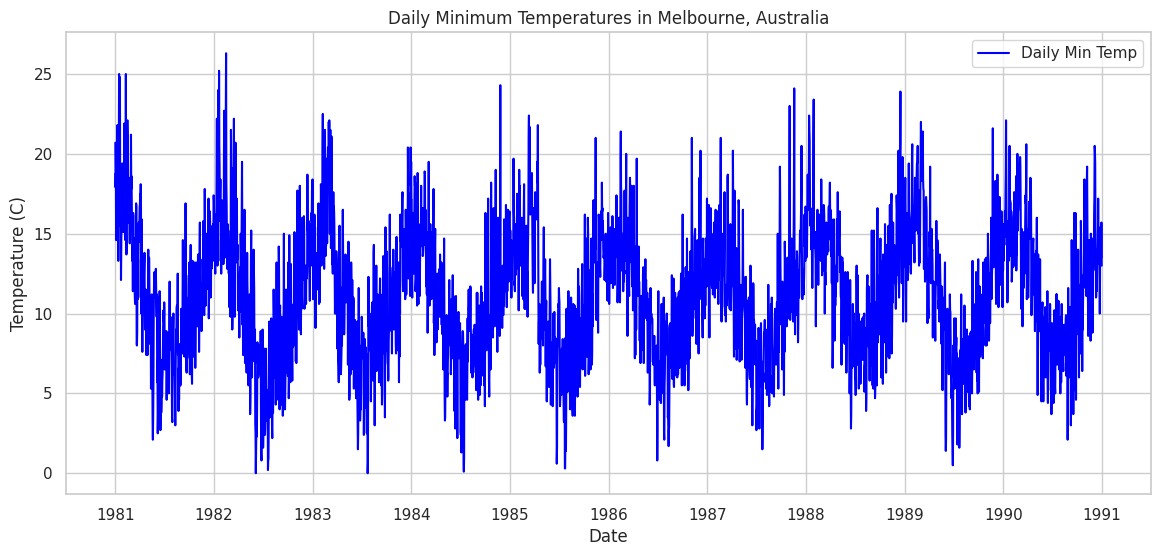

In [12]:
plt.figure()
plt.plot(df['Temp'],color='blue',label='Daily Min Temp')
plt.title('Daily Minimum Temperatures in Melbourne, Australia')
plt.xlabel('Date')
plt.ylabel('Temperature (C)')
plt.legend()
plt.show()

### Distribution Analysis: Histogram & KDE

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


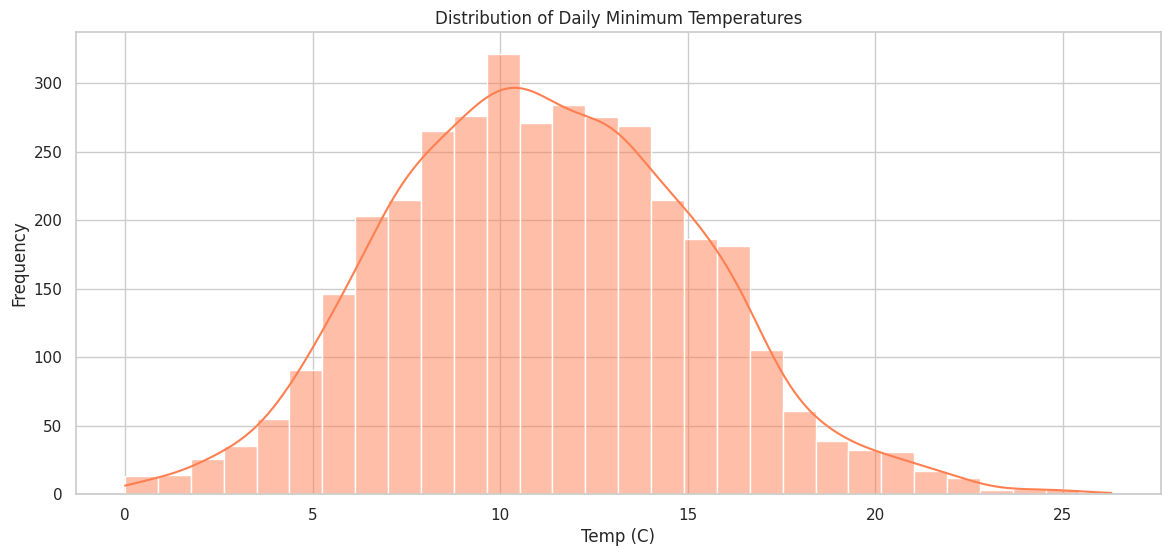

In [13]:
plt.figure()
sns.histplot(df['Temp'], bins = 30, kde = True, color='coral')
plt.title('Distribution of Daily Minimum Temperatures')
plt.xlabel('Temp (C)')
plt.ylabel('Frequency')
plt.show()

### Box Plot by Month to Visualize Seasonality

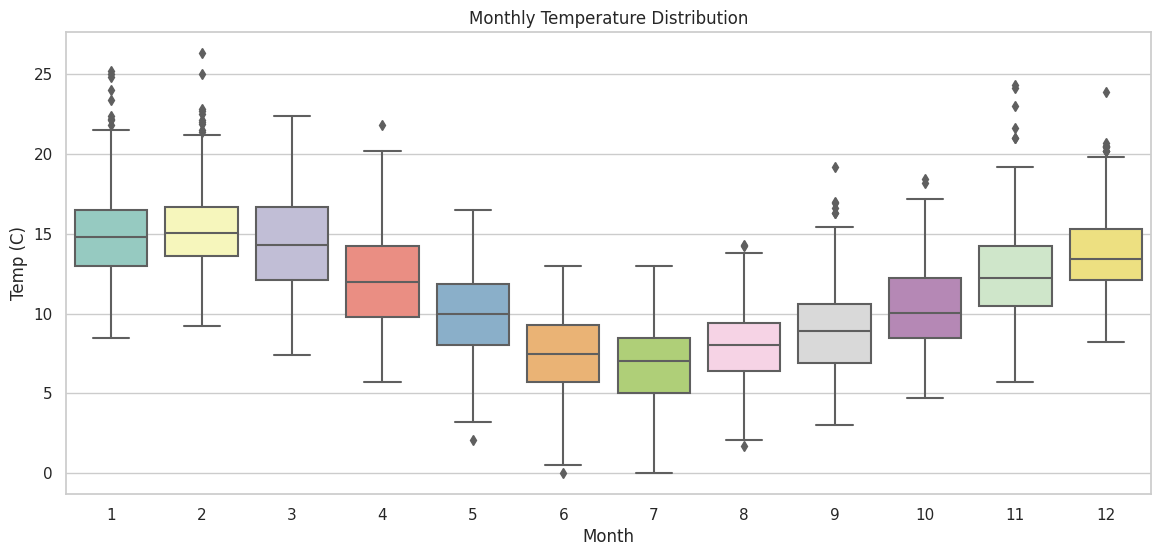

In [14]:
plt.figure()
sns.boxplot(x='Month', y = 'Temp', data=df, palette='Set3')
plt.title('Monthly Temperature Distribution')
plt.xlabel('Month')
plt.ylabel('Temp (C)')
plt.show()

### Seasonal Decomposition using STL

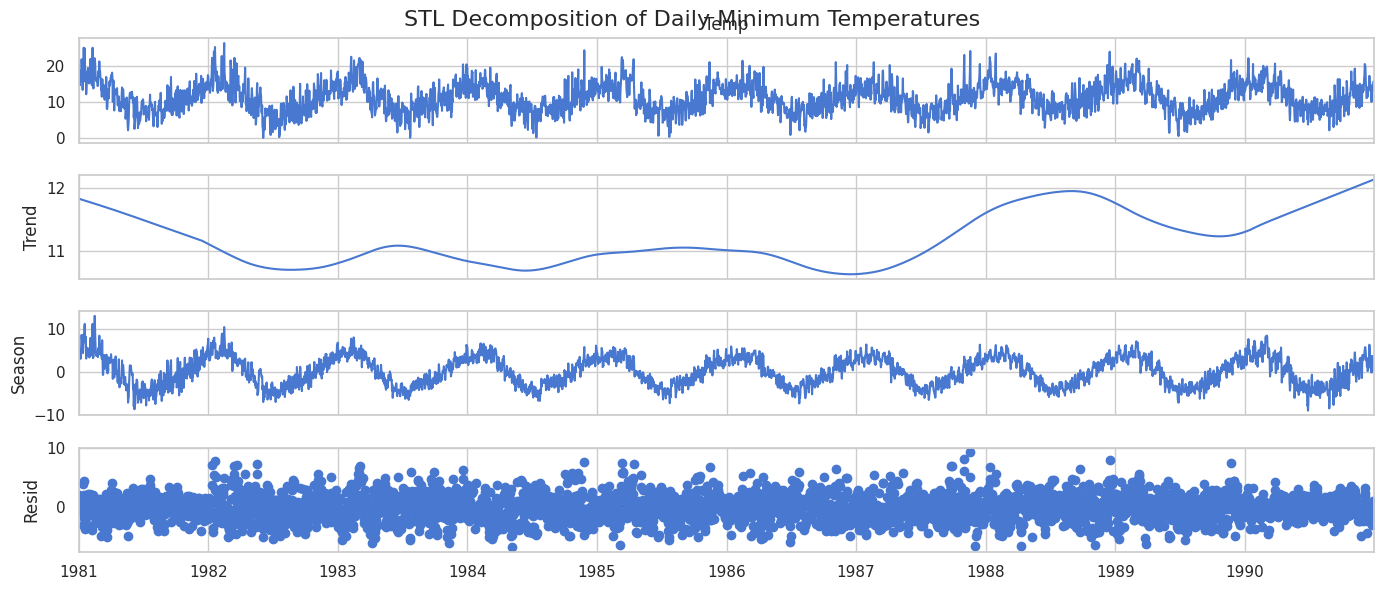

In [15]:
stl = STL(df['Temp'],period=365)
result = stl.fit()
result.plot()
plt.suptitle('STL Decomposition of Daily Minimum Temperatures', fontsize=16)
plt.show()

### Rolling Statistics: 30-day Rolling Mean & Std Dev

In [16]:
df['Rolling_Mean_30'] = df['Temp'].rolling(window=30).mean()
df['Rolling_Std_30'] = df['Temp'].rolling(window=30).std()

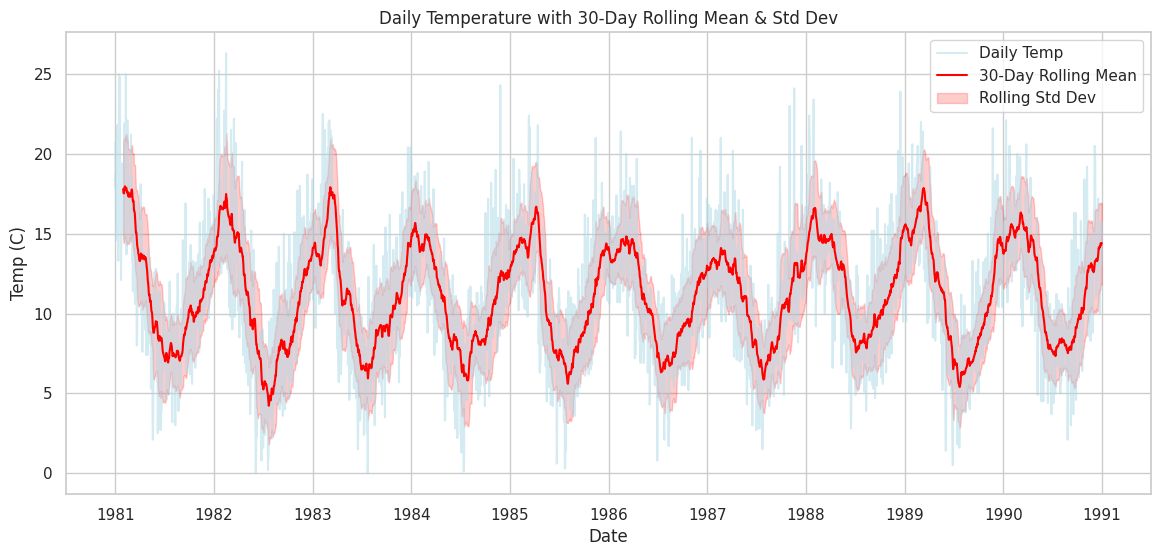

In [17]:
plt.figure()
plt.plot(df['Temp'], label = 'Daily Temp', color = 'lightblue',alpha=0.5)
plt.plot(df['Rolling_Mean_30'],label='30-Day Rolling Mean', color='red')
plt.fill_between(df.index,df['Rolling_Mean_30'] - df['Rolling_Std_30'],
                 df['Rolling_Mean_30'] + df['Rolling_Std_30'],
                 color='red', alpha=0.2, label='Rolling Std Dev')
plt.title('Daily Temperature with 30-Day Rolling Mean & Std Dev')
plt.xlabel('Date')
plt.ylabel('Temp (C)')
plt.legend()
plt.show()